# One Country, Too Many Nations — Companion Data

Reproducible data and code for the Ahmadi Research blog post
**"One Country, Too Many Nations: What America Got Wrong in Afghanistan"**.

- Live post: https://ahmadiresearch.com/blog/one-country-too-many-nations/
- Author: Mohammad Ahmadi

This notebook regenerates every chart from the live post in matplotlib.
Every data point is cited inline. Every assumption is written down — change
it, rerun, and see what breaks. That is the point.

> *"If someone with the same data can't get to the same conclusion, the analysis isn't done."*


## Setup

```bash
pip install -r requirements.txt
jupyter notebook Afghanistan_Data.ipynb
```

Dependencies: `pandas`, `numpy`, `matplotlib`. No proprietary data, no black boxes.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Ellipse, Polygon, FancyBboxPatch
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch
from matplotlib.transforms import Affine2D

# Brand palette (matches the website blog post exactly)
BRAND = {
    'blue_main':   '#005a96',
    'blue_soft':   '#0f80c4',
    'blue_light':  '#8fd1ff',
    'title_blue':  '#13597B',
    # Atlas palette for ethnic regions (Chart 2)
    'pashtun':  '#2c6c91',
    'tajik':    '#c2941c',
    'hazara':   '#9c4869',
    'uzbek':    '#5d8a5e',
    'turkmen':  '#d39559',
    'aimaq':    '#8c7aae',
    'baluch':   '#b15c47',
}

# Global matplotlib styling — matches website's clean cartographic look
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.18,
    'grid.linestyle':    '-',
    'axes.axisbelow':    True,
    'axes.titleweight':  '600',
    'axes.titlesize':    13,
    'axes.titlelocation':'left',
    'axes.titlepad':     14,
    'figure.facecolor':  'white',
})


---

## Chart 1 — Marshall Plan vs. Afghanistan Reconstruction

Both nominal and inflation-adjusted to 2024 USD.

**Sources**

- Marshall Plan: National Museum of American Diplomacy, *The Marshall Plan*. Sixteen OEEC recipients
  (Austria, Belgium, Denmark, France, Greece, Iceland, Ireland, Italy, Luxembourg, Netherlands, Norway,
  Portugal, Sweden, Turkey, UK, West Germany). $13.3B nominal converts to ~$150B in 2024 dollars.
- Afghanistan: Costs of War Project, Watson Institute, Brown University. Cumulative U.S. spending of
  $2.313T through fiscal-year 2021 reporting, mixing year-of-spending dollars (2001–2021). Adjusting
  the weighted-average year (~2012) to 2024 yields roughly $2.6T in 2024 dollars (~+12%, BLS CPI).

**Assumptions you can argue with**
1. The Brown $2.3T figure includes Pentagon ops, State Dept, vets care to date, and interest on war
   borrowing — but excludes future veterans care (~$2.2T projected to 2050+). Including future vets
   care pushes the total closer to $4.5T.
2. The 2024-dollar adjustment uses a single weighted-average year. A year-by-year deflation would be
   more precise but doesn't materially change the ratio.


In [2]:
spend = pd.DataFrame({
    'Program':      ['Marshall Plan', 'Afghanistan'],
    'Countries':    [16, 1],
    'Years':        ['1948-1952', '2001-2021'],
    'Nominal_B':    [13.3, 2313.0],
    'Real2024_B':   [150.0, 2600.0],
    'Outcome':      ['Stable democracies', 'State collapse'],
})
spend['Per_Country_2024_B'] = spend['Real2024_B'] / spend['Countries']
spend['Ratio_to_Marshall_Real'] = spend['Real2024_B'] / spend.loc[0, 'Real2024_B']
spend


,Program,Countries,Years,Nominal_B,Real2024_B,Outcome,Per_Country_2024_B,Ratio_to_Marshall_Real
0,Marshall Plan,16,1948-1952,13.3,150.0,Stable democracies,9.375,1.000000
1,Afghanistan,1,2001-2021,2313.0,2600.0,State collapse,2600.000,17.333333


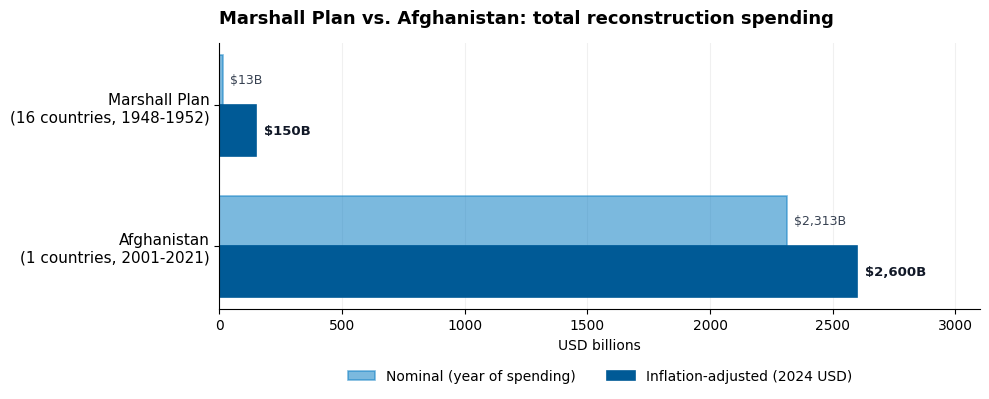


Ratio (real 2024 dollars): Afghanistan / Marshall = 17.3x


In [3]:
fig, ax = plt.subplots(figsize=(10, 4.2))
y = np.arange(len(spend))
h = 0.36

ax.barh(y - h/2, spend['Nominal_B'],  h, label='Nominal (year of spending)',
        color=BRAND['blue_soft'], alpha=0.55, edgecolor=BRAND['blue_soft'], linewidth=1.2)
ax.barh(y + h/2, spend['Real2024_B'], h, label='Inflation-adjusted (2024 USD)',
        color=BRAND['blue_main'], edgecolor=BRAND['blue_main'], linewidth=1.2)

for i, row in spend.iterrows():
    ax.text(row['Nominal_B'] + 30, i - h/2,
            f"${row['Nominal_B']:,.0f}B", va='center', fontsize=9, color='#374151')
    ax.text(row['Real2024_B'] + 30, i + h/2,
            f"${row['Real2024_B']:,.0f}B", va='center', fontsize=9.5, color='#111827', fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels([f"{p}\n({c} countries, {yr})" for p, c, yr in
                    zip(spend['Program'], spend['Countries'], spend['Years'])],
                   fontsize=11)
ax.invert_yaxis()
ax.set_xlabel('USD billions')
ax.set_xlim(0, 3100)
ax.set_title('Marshall Plan vs. Afghanistan: total reconstruction spending')
# Legend above the plot area so it never overlaps the long Afghanistan bar
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2,
          frameon=False, fontsize=10, columnspacing=2.2)
ax.grid(axis='x', alpha=0.18)
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

print(f"\nRatio (real 2024 dollars): Afghanistan / Marshall = "
      f"{spend.loc[1,'Real2024_B'] / spend.loc[0,'Real2024_B']:.1f}x")


---

## Chart 2 — Ethnic Geography of Afghanistan

The blog post renders this as a stylized SVG map. Below is a matplotlib version of the same map:
real Afghanistan country outline (from open vector data), colored ethnic-region overlays clipped to
the country, and the Hindu Kush spine running NE→SW.

No national census in Afghanistan since 1979 — population shares are estimates from
Minority Rights Group International.


In [4]:
AFG_OUTLINE = [
    (735.0, 128.3), (722.6, 140.8), (720.8, 144.7), (719.5, 147.9), (719.0, 150.0), (718.5, 151.7),
    (717.2, 153.5), (714.9, 155.6), (712.0, 158.0), (709.8, 160.3), (708.4, 162.7), (707.5, 165.2),
    (706.3, 167.4), (704.4, 169.4), (701.3, 171.6), (697.2, 174.8), (696.0, 178.4), (697.1, 183.8),
    (698.6, 188.2), (699.4, 191.6), (699.9, 195.0), (700.0, 198.5), (699.8, 201.5), (698.8, 203.0),
    (696.6, 204.3), (694.8, 205.4), (693.5, 206.7), (692.7, 208.3), (692.2, 209.9), (691.8, 211.1),
    (691.4, 211.8), (690.9, 211.9), (689.6, 211.2), (687.4, 209.9), (684.7, 208.1), (668.2, 205.1),
    (663.1, 205.6), (658.2, 205.9), (654.3, 206.0), (636.8, 222.0), (636.5, 238.9), (623.0, 235.8),
    (619.0, 233.3), (616.1, 231.6), (614.6, 231.0), (613.0, 231.3), (609.5, 231.8), (604.9, 232.6),
    (598.9, 233.7), (594.2, 234.9), (591.0, 236.4), (587.8, 238.8), (583.7, 241.4), (578.4, 243.9),
    (570.2, 247.0), (565.2, 248.9), (560.2, 251.2), (556.0, 253.5), (553.0, 255.4), (550.5, 256.9),
    (548.7, 257.8), (548.0, 257.9), (546.1, 257.0), (542.8, 255.1), (538.7, 252.7), (533.7, 249.5),
    (530.4, 246.8), (528.2, 244.3), (526.6, 241.7), (524.2, 239.4), (520.7, 237.1), (509.0, 230.9),
    (481.4, 228.6), (461.6, 220.7), (454.9, 220.2), (448.1, 220.5), (437.9, 221.9), (427.8, 223.3),
    (422.3, 223.6), (418.3, 223.0), (414.6, 221.8), (411.8, 220.4), (409.4, 218.4), (406.7, 215.3),
    (404.4, 213.1), (402.1, 212.2), (398.6, 212.0), (395.1, 211.7), (391.5, 210.9), (387.5, 209.5),
    (383.7, 207.9), (380.8, 206.8), (379.0, 206.2), (378.4, 206.4), (377.3, 208.5), (375.3, 212.5),
    (372.7, 217.6), (369.9, 222.8), (367.5, 226.8), (365.8, 229.1), (364.2, 229.6), (359.8, 229.8),
    (353.4, 230.0), (333.0, 230.0), (310.7, 249.5), (310.1, 254.2), (308.7, 258.5), (306.2, 263.9),
    (302.7, 270.6), (300.7, 275.3), (300.1, 279.6), (300.0, 285.5), (299.6, 290.1), (298.3, 294.1),
    (295.3, 299.7), (292.0, 305.1), (288.7, 309.0), (284.0, 313.0), (267.7, 320.5), (255.5, 332.2),
    (249.8, 331.1), (246.1, 330.8), (241.8, 330.6), (236.7, 330.6), (231.8, 331.0), (227.6, 332.0),
    (222.8, 333.8), (218.1, 335.5), (211.8, 337.4), (205.1, 339.1), (199.0, 340.5), (194.0, 341.6),
    (190.9, 342.4), (190.1, 342.7), (190.4, 344.1), (191.3, 346.5), (192.5, 349.6), (191.6, 359.5),
    (190.0, 361.5), (189.0, 364.2), (188.2, 368.4), (187.7, 371.5), (187.2, 374.0), (186.9, 375.4),
    (185.7, 376.1), (180.9, 378.5), (173.2, 382.4), (162.0, 388.1), (151.9, 392.9), (147.3, 394.4),
    (145.0, 393.7), (143.2, 392.8), (141.4, 393.1), (138.4, 394.7), (135.2, 396.6), (132.9, 398.0),
    (131.4, 398.8), (130.8, 398.9), (130.6, 398.2), (130.7, 396.8), (131.0, 394.9), (131.3, 392.0),
    (129.8, 388.9), (125.3, 383.3), (107.4, 372.3), (102.8, 373.7), (98.6, 374.1), (92.2, 373.6),
    (71.6, 362.9), (68.0, 357.5), (65.7, 354.9), (63.7, 354.0), (59.7, 354.2), (56.5, 355.9),
    (54.2, 360.6), (52.1, 367.9), (50.5, 373.3), (48.8, 378.4), (47.4, 382.2), (46.3, 385.3),
    (45.5, 388.5), (45.0, 391.2), (44.9, 393.5), (44.3, 396.7), (43.3, 400.3), (42.0, 404.2),
    (40.9, 408.3), (40.5, 412.5), (40.7, 418.5), (34.7, 436.6), (31.4, 440.3), (28.3, 442.5),
    (23.8, 444.5), (20.7, 445.8), (18.3, 446.9), (17.1, 447.7), (17.5, 449.3), (19.7, 452.6),
    (22.9, 456.2), (26.4, 459.3), (28.5, 461.3), (29.3, 463.0), (29.1, 464.8), (28.4, 466.5),
    (26.3, 467.4), (21.6, 467.9), (5.4, 473.5), (2.2, 477.7), (1.1, 482.2), (1.6, 490.1),
    (2.4, 497.7), (2.5, 501.9), (2.0, 505.6), (1.0, 509.7), (0.3, 513.0), (0.6, 515.6),
    (2.0, 519.3), (15.8, 528.1), (21.4, 530.3), (24.8, 532.6), (26.0, 535.0), (25.3, 535.9),
    (23.6, 537.6), (21.1, 539.7), (17.8, 542.4), (15.2, 545.0), (13.4, 547.6), (12.3, 550.1),
    (10.7, 552.8), (8.4, 555.8), (6.0, 558.5), (3.0, 561.7), (1.5, 564.0), (1.0, 566.5),
    (1.4, 570.6), (3.5, 580.8), (6.9, 595.6), (12.1, 617.3), (16.5, 637.5), (17.3, 648.3),
    (15.4, 658.7), (19.7, 676.9), (15.5, 681.0), (14.4, 683.4), (14.0, 687.9), (14.0, 703.7),
    (55.7, 716.7), (69.7, 722.1), (76.0, 726.8), (77.7, 730.8), (78.5, 732.9), (79.7, 735.5),
    (81.1, 738.0), (82.0, 756.3), (80.9, 762.0), (79.6, 765.4), (77.2, 768.5), (73.3, 772.8),
    (66.2, 780.8), (57.2, 790.8), (32.5, 824.1), (31.0, 829.3), (29.0, 833.0), (25.4, 837.2),
    (21.4, 841.2), (18.8, 844.0), (17.3, 845.9), (17.9, 846.7), (27.7, 850.8), (46.5, 858.5),
    (71.2, 868.5), (158.5, 888.9), (172.4, 888.2), (184.2, 887.5), (191.6, 886.9), (198.0, 886.3),
    (204.3, 886.5), (214.0, 887.8), (226.8, 889.8), (234.2, 891.4), (238.1, 892.9), (240.9, 895.0),
    (243.9, 897.1), (246.8, 898.5), (249.1, 899.0), (249.5, 898.6), (249.8, 897.6), (250.0, 896.2),
    (250.1, 894.1), (250.9, 892.0), (252.5, 889.6), (255.6, 886.4), (260.5, 883.0), (267.2, 880.2),
    (276.8, 877.7), (321.2, 887.0), (413.6, 854.3), (407.0, 839.3), (412.3, 821.8), (413.8, 816.3),
    (414.8, 812.7), (415.0, 811.5), (414.5, 810.4), (413.7, 809.0), (412.5, 807.4), (411.3, 805.7),
    (410.5, 804.2), (410.0, 803.1), (410.3, 801.6), (411.5, 797.5), (413.4, 791.2), (420.1, 771.2),
    (428.6, 768.8), (431.1, 767.6), (432.4, 766.1), (433.2, 764.0), (434.0, 762.3), (434.8, 760.8),
    (435.7, 759.8), (436.9, 758.6), (438.6, 756.7), (440.5, 754.2), (444.9, 749.2), (452.3, 743.5),
    (460.0, 739.8), (468.8, 739.0), (470.5, 745.7), (471.3, 747.4), (472.5, 747.8), (474.4, 747.5),
    (477.8, 747.0), (483.0, 746.2), (489.0, 745.5), (501.3, 743.3), (513.4, 740.3), (521.5, 737.4),
    (523.1, 736.2), (523.6, 735.2), (524.0, 734.2), (524.2, 733.0), (523.7, 732.0), (521.6, 731.2),
    (517.2, 730.4), (512.0, 729.4), (509.1, 727.9), (508.1, 725.8), (509.4, 723.5), (515.6, 720.2),
    (524.4, 716.5), (532.3, 713.7), (538.3, 709.3), (544.1, 703.3), (547.3, 697.9), (548.0, 696.1),
    (549.2, 695.2), (551.7, 695.0), (555.2, 695.1), (557.5, 695.5), (559.0, 696.6), (560.6, 698.5),
    (562.4, 700.1), (564.9, 701.4), (568.3, 702.5), (571.3, 703.3), (573.8, 704.1), (575.4, 704.6),
    (576.2, 704.8), (576.7, 704.4), (576.9, 703.2), (576.7, 701.2), (576.9, 699.4), (578.0, 698.4),
    (580.4, 697.4), (588.5, 701.0), (590.8, 703.6), (593.3, 706.3), (595.5, 708.8), (613.6, 711.7),
    (633.0, 657.1), (648.9, 622.4), (647.5, 609.8), (647.2, 591.2), (654.0, 587.6), (657.3, 586.5),
    (661.1, 585.8), (665.5, 585.4), (671.2, 584.4), (678.3, 583.0), (685.6, 581.2), (704.6, 567.9),
    (706.3, 564.3), (707.5, 561.6), (708.0, 560.4), (707.3, 559.4), (705.5, 557.4), (703.0, 554.6),
    (698.6, 549.6), (695.9, 544.7), (696.2, 540.3), (698.6, 536.2), (699.8, 534.1), (699.2, 533.2),
    (696.8, 533.0), (694.6, 532.7), (691.5, 531.8), (688.2, 530.6), (677.9, 520.0), (676.0, 514.4),
    (675.8, 510.9), (677.4, 507.9), (679.5, 505.7), (681.3, 504.6), (683.6, 504.1), (686.9, 503.9),
    (690.3, 504.4), (694.5, 506.2), (701.2, 509.7), (728.2, 513.9), (740.3, 511.8), (751.5, 509.3),
    (757.7, 507.1), (758.7, 506.0), (760.5, 503.7), (762.8, 500.6), (765.9, 496.4), (768.0, 492.5),
    (769.3, 488.7), (771.1, 478.8), (765.2, 471.0), (763.7, 468.1), (763.1, 465.3), (763.0, 461.7),
    (763.4, 458.7), (764.4, 456.3), (766.3, 453.6), (768.1, 450.9), (769.9, 447.4), (771.4, 443.4),
    (772.5, 439.7), (773.4, 436.8), (774.0, 434.9), (774.4, 434.3), (777.0, 433.0), (781.7, 430.6),
    (787.8, 427.6), (793.8, 424.5), (798.4, 422.0), (800.8, 420.4), (800.9, 419.8), (800.7, 418.5),
    (800.3, 416.7), (799.9, 414.3), (799.8, 411.9), (800.4, 410.3), (802.1, 408.4), (801.6, 402.1),
    (800.3, 400.3), (800.2, 398.2), (801.0, 394.7), (801.7, 390.9), (801.4, 387.5), (800.0, 382.3),
    (798.1, 376.3), (796.8, 370.7), (795.8, 365.2), (794.8, 353.1), (787.1, 347.6), (783.6, 344.7),
    (780.1, 341.6), (772.8, 334.2), (788.8, 311.9), (793.9, 304.9), (797.5, 300.2), (799.2, 298.4),
    (800.9, 297.8), (804.0, 298.3), (809.9, 300.1), (814.3, 301.4), (817.6, 302.3), (819.4, 302.7),
    (819.8, 302.2), (820.5, 300.1), (821.5, 296.8), (822.7, 292.8), (823.8, 289.2), (824.8, 286.6),
    (825.3, 285.4), (826.4, 285.0), (829.0, 284.5), (832.4, 284.0), (838.5, 283.0), (844.1, 280.8),
    (850.4, 275.7), (865.5, 261.2), (902.6, 259.3), (914.6, 258.8), (923.0, 258.8), (926.6, 259.0),
    (929.4, 259.1), (932.7, 258.4), (937.1, 257.0), (973.8, 264.3), (979.9, 259.6), (983.1, 258.0),
    (987.2, 256.6), (993.1, 255.2), (999.8, 253.0), (1004.3, 250.7), (1006.0, 248.4), (1005.7, 246.9),
    (1004.7, 243.9), (1003.5, 240.1), (1001.9, 235.6), (1000.8, 231.7), (1000.4, 228.8), (1000.7, 226.2),
    (1001.6, 224.0), (1003.1, 223.5), (1005.5, 224.2), (1007.2, 224.7), (1008.7, 224.4), (1010.5, 223.0),
    (1018.3, 221.1), (1023.5, 219.9), (1023.8, 218.4), (1023.4, 217.1), (1022.1, 215.6), (1018.4, 213.0),
    (1013.8, 211.6), (1009.6, 211.6), (1007.4, 212.5), (1006.0, 212.6), (1004.3, 211.7), (1001.9, 210.0),
    (999.5, 208.7), (996.7, 208.1), (992.5, 208.0), (988.3, 208.1), (985.6, 208.7), (983.7, 209.8),
    (981.8, 211.3), (978.9, 212.7), (975.0, 214.1), (970.5, 215.4), (965.5, 216.9), (960.2, 218.5),
    (955.7, 220.1), (949.3, 222.3), (946.6, 222.8), (947.1, 221.5), (948.7, 219.6), (949.4, 218.2),
    (949.4, 216.6), (948.6, 214.4), (947.7, 212.8), (946.3, 212.1), (943.9, 212.0), (941.7, 211.8),
    (939.1, 211.4), (936.8, 210.7), (934.1, 209.7), (931.0, 209.4), (926.1, 210.2), (919.0, 211.9),
    (913.8, 213.1), (909.8, 214.1), (907.8, 214.6), (906.9, 215.3), (905.9, 216.7), (905.0, 218.6),
    (896.8, 224.4), (892.5, 225.1), (890.0, 226.4), (887.8, 229.0), (885.5, 232.2), (882.8, 235.7),
    (879.7, 239.4), (872.0, 247.8), (861.0, 249.4), (857.3, 250.1), (854.6, 250.7), (853.0, 251.3),
    (849.3, 253.9), (843.3, 258.6), (836.0, 264.5), (823.8, 274.5), (817.5, 278.9), (812.6, 280.6),
    (800.3, 277.8), (795.2, 271.6), (790.0, 263.3), (785.6, 254.3), (783.2, 247.8), (782.3, 243.9),
    (782.4, 239.8), (783.1, 234.4), (784.1, 229.6), (785.4, 224.7), (786.7, 220.7), (786.5, 207.7),
    (785.6, 200.9), (786.4, 193.5), (789.1, 187.1), (790.7, 184.4), (791.6, 181.8), (792.0, 179.1),
    (792.0, 176.2), (791.7, 174.6), (790.8, 174.3), (789.4, 174.7), (787.9, 175.2), (786.3, 175.9),
    (784.8, 176.6), (783.0, 177.3), (780.5, 177.7), (777.9, 178.0), (774.7, 178.0), (772.7, 177.5),
    (771.7, 176.3), (771.0, 174.0), (770.8, 171.3), (771.0, 168.0), (771.6, 163.9), (772.2, 159.8),
    (772.6, 155.4), (772.9, 151.5), (765.5, 140.1), (761.2, 137.6), (756.4, 134.4), (752.0, 131.3),
    (748.5, 128.7), (745.6, 126.6), (743.6, 125.3), (742.9, 125.0), (741.3, 125.6), (738.5, 126.8),
    (735.0, 128.3), (735.0, 128.3),
]

ethnic = pd.DataFrame([
    {'group': 'Pashtun',  'share_pct': 42, 'color': BRAND['pashtun'],  'homeland': 'South & east (Kandahar, Helmand, Khost, Nangarhar)'},
    {'group': 'Tajik',    'share_pct': 27, 'color': BRAND['tajik'],    'homeland': 'NE (Badakhshan, Panjshir), Wakhan, Herat, Kabul enclave'},
    {'group': 'Hazara',   'share_pct': 9,  'color': BRAND['hazara'],   'homeland': 'Central highlands (Bamyan, Daikundi)'},
    {'group': 'Uzbek',    'share_pct': 9,  'color': BRAND['uzbek'],    'homeland': 'Northern plains (Faryab, Jowzjan, Balkh)'},
    {'group': 'Aimaq',    'share_pct': 4,  'color': BRAND['aimaq'],    'homeland': 'West-central (Ghor, Badghis)'},
    {'group': 'Turkmen',  'share_pct': 3,  'color': BRAND['turkmen'],  'homeland': 'Northwest (Faryab, Jowzjan)'},
    {'group': 'Baluch',   'share_pct': 2,  'color': BRAND['baluch'],   'homeland': 'Southwest (Nimroz)'},
])
print(f"Total accounted for: {ethnic['share_pct'].sum()}% (smaller groups make up the rest)")
ethnic


Total accounted for: 96% (smaller groups make up the rest)


,group,share_pct,color,homeland
0,Pashtun,42,#2c6c91,"South & east (Kandahar, Helmand, Khost, Nangar..."
1,Tajik,27,#c2941c,"NE (Badakhshan, Panjshir), Wakhan, Herat, Kabu..."
2,Hazara,9,#9c4869,"Central highlands (Bamyan, Daikundi)"
3,Uzbek,9,#5d8a5e,"Northern plains (Faryab, Jowzjan, Balkh)"
4,Aimaq,4,#8c7aae,"West-central (Ghor, Badghis)"
5,Turkmen,3,#d39559,"Northwest (Faryab, Jowzjan)"
6,Baluch,2,#b15c47,Southwest (Nimroz)


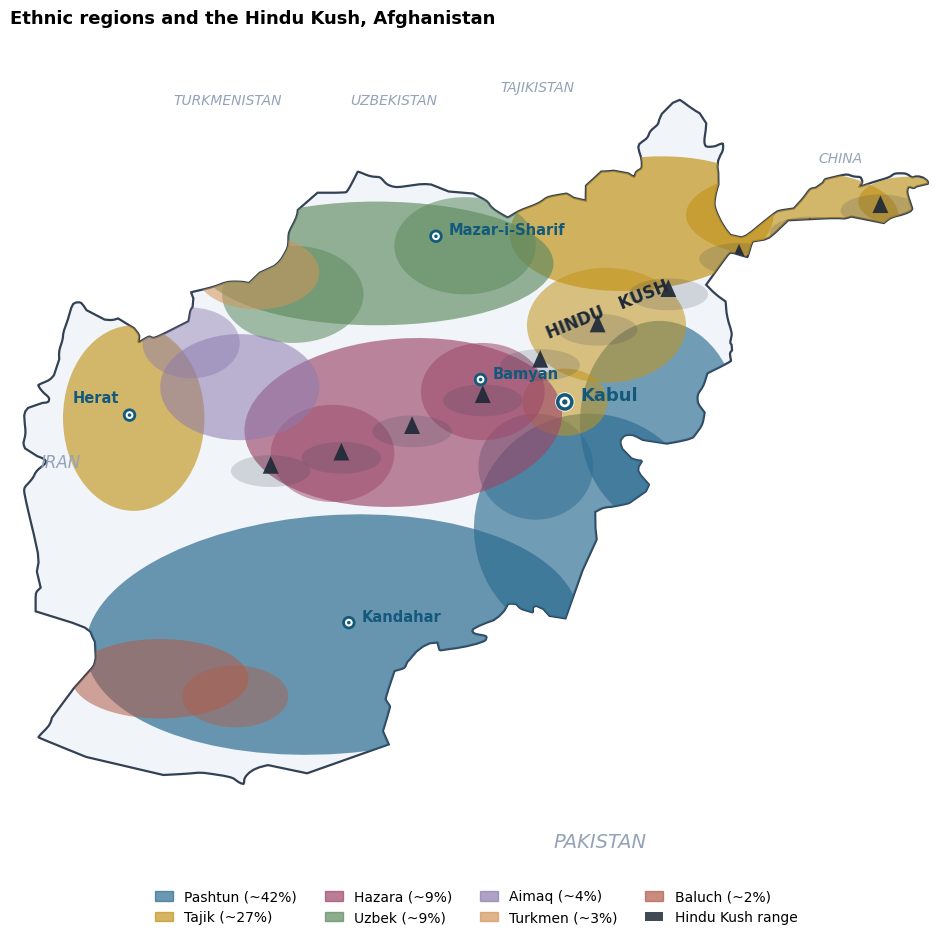

In [5]:
# Build the map: country outline → ethnic-region ellipses → Hindu Kush peaks → cities → labels.
# Coordinates are computed from real lat/lon via equirectangular projection over the country bounds
# (x: 0–1024 → lon 60.5–75°E; y: 125–899 → lat 38.5–29.5°N).

CITIES = [
    # (name, lat, lon, is_capital)
    ('Kabul',          34.526, 69.178, True),
    ('Kandahar',       31.622, 65.717, False),
    ('Herat',          34.353, 62.203, False),
    ('Mazar-i-Sharif', 36.706, 67.113, False),
    ('Bamyan',         34.821, 67.828, False),
]

def ll_to_xy(lat, lon):
    x = (lon - 60.5) / 14.5 * 1024
    y = (38.5 - lat) /  9.0 * 774 + 125
    return x, y

# Ethnic-region ellipse layout (cx, cy, rx, ry, color, alpha, rotate_deg)
REGIONS = [
    # Pashtun south + east + NE arm + Logar pocket
    (350, 730, 280, 135, BRAND['pashtun'], 0.70, -4),
    (640, 610, 130, 130, BRAND['pashtun'], 0.65, -30),
    (720, 490,  90, 115, BRAND['pashtun'], 0.65,   0),
    (580, 540,  65,  60, BRAND['pashtun'], 0.50,   0),
    # Tajik NE Badakhshan + Wakhan + Panjshir
    (700, 265, 150,  75, BRAND['tajik'],   0.70,  -6),
    (870, 255, 120,  50, BRAND['tajik'],   0.65,   0),
    (1000, 240, 55,  28, BRAND['tajik'],   0.65,   0),
    (660, 380,  90,  65, BRAND['tajik'],   0.55,   0),
    # Tajik Herat
    (125, 485,  80, 105, BRAND['tajik'],   0.65,   0),
    # Tajik Kabul enclave
    (613, 467,  48,  38, BRAND['tajik'],   0.55,   0),
    # Hazara highlands
    (430, 490, 180,  95, BRAND['hazara'],  0.65,  -4),
    (520, 455,  70,  55, BRAND['hazara'],  0.55,   0),
    (350, 525,  70,  55, BRAND['hazara'],  0.50,   0),
    # Uzbek north
    (400, 310, 200,  70, BRAND['uzbek'],   0.65,   0),
    (500, 290,  80,  55, BRAND['uzbek'],   0.55,   0),
    (305, 345,  80,  55, BRAND['uzbek'],   0.55,   0),
    # Turkmen NW
    (265, 320,  70,  42, BRAND['turkmen'], 0.55,   0),
    # Aimaq W central
    (245, 450,  90,  60, BRAND['aimaq'],   0.55,   0),
    (190, 400,  55,  40, BRAND['aimaq'],   0.45,   0),
    # Baluch SW
    (155, 780, 100,  45, BRAND['baluch'],  0.55,   0),
    (240, 800,  60,  35, BRAND['baluch'],  0.45,   0),
]

# Hindu Kush peaks along NE→SW spine (x, y) from Wakhan tip to western Koh-e Baba
PEAKS = [
    (970, 245), (890, 270), (810, 300), (730, 340), (650, 380),
    (585, 420), (520, 460), (440, 495), (360, 525), (280, 540),
]

fig, ax = plt.subplots(figsize=(11, 9.5))
ax.set_xlim(-15, 1040)
ax.set_ylim(995, 60)  # invert y so the country renders right-side-up; extra room top + bottom
ax.set_aspect('equal')
ax.axis('off')

# Country path (used for fill AND clipping)
country_path = MplPath([(x, y) for x, y in AFG_OUTLINE] + [(0, 0)],
                       [MplPath.MOVETO] + [MplPath.LINETO]*(len(AFG_OUTLINE)-1) + [MplPath.CLOSEPOLY])
country_patch = PathPatch(country_path, facecolor='#f1f5f9', edgecolor='#334155',
                           linewidth=1.6, zorder=1)
ax.add_patch(country_patch)

# Ethnic regions, clipped to country
for cx, cy, rx, ry, color, alpha, rot in REGIONS:
    e = Ellipse((cx, cy), rx*2, ry*2, angle=rot, facecolor=color,
                edgecolor='none', alpha=alpha, zorder=2)
    ax.add_patch(e)
    e.set_clip_path(country_patch)

# Hindu Kush peaks (small triangles + a soft halo each)
for px, py in PEAKS:
    halo = Ellipse((px, py+5), 90, 36, facecolor='#374151', edgecolor='none', alpha=0.18, zorder=3)
    ax.add_patch(halo); halo.set_clip_path(country_patch)
    tri = Polygon([(px-9, py+8), (px, py-12), (px+9, py+8)],
                  closed=True, facecolor='#1f2937', alpha=0.92, zorder=4)
    ax.add_patch(tri); tri.set_clip_path(country_patch)

# Hindu Kush range label, rotated along the spine
ax.text(595, 395, 'HINDU   KUSH', fontsize=12, fontweight='700',
        color='#1f2937', rotation=22, rotation_mode='anchor', zorder=5)

# City markers and labels
for name, lat, lon, is_capital in CITIES:
    x, y = ll_to_xy(lat, lon)
    if is_capital:
        ax.add_patch(Ellipse((x, y), 22, 22, facecolor='white', alpha=0.85, edgecolor='none', zorder=5))
        ax.add_patch(Ellipse((x, y), 16, 16, facecolor='white', edgecolor=BRAND['title_blue'], linewidth=2.5, zorder=5))
        ax.add_patch(Ellipse((x, y),  6,  6, facecolor=BRAND['title_blue'], edgecolor='none', zorder=5))
        ax.text(x+18, y-2, name, fontsize=13, fontweight='700', color=BRAND['title_blue'], zorder=6)
    else:
        ax.add_patch(Ellipse((x, y), 12, 12, facecolor='white', edgecolor=BRAND['title_blue'], linewidth=2, zorder=5))
        ax.add_patch(Ellipse((x, y),  4,  4, facecolor=BRAND['title_blue'], edgecolor='none', zorder=5))
        if name == 'Herat':
            ax.text(x-12, y-15, name, fontsize=10.5, fontweight='600', color=BRAND['title_blue'],
                    ha='right', zorder=6)
        else:
            ax.text(x+14, y-2, name, fontsize=10.5, fontweight='600', color=BRAND['title_blue'], zorder=6)

# Bordering country labels (italic, light grey)
borders = [
    ('IRAN',         20, 540, 12),
    ('PAKISTAN',    600, 970, 14),
    ('TURKMENISTAN',170, 130, 10),
    ('UZBEKISTAN',  370, 130, 10),
    ('TAJIKISTAN',  540, 115, 10),
    ('CHINA',       900, 195, 10),
]
for txt, x, y, sz in borders:
    ax.text(x, y, txt, fontsize=sz, color='#94a3b8', fontstyle='italic', fontweight='500', zorder=2)

ax.set_title('Ethnic regions and the Hindu Kush, Afghanistan')

# Legend (atlas palette)
handles = [Patch(facecolor=row['color'], edgecolor=row['color'], alpha=0.70,
                 label=f"{row['group']} (~{row['share_pct']}%)")
           for _, row in ethnic.iterrows()]
handles.append(Patch(facecolor='#1f2937', edgecolor='none', alpha=0.85, label='Hindu Kush range'))
ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.01),
          ncol=4, frameon=False, fontsize=10, columnspacing=2.0, handlelength=1.3)

plt.tight_layout()
plt.show()


---

## Chart 3 — Pashtun Rule Timeline, 1747 – 2021

Of the ~274 years between Ahmad Shah Durrani's founding of the Durrani Empire (1747) and the
republic's collapse (2021), Pashtun-led leadership held power for roughly 269 years. Two brief
Tajik exceptions:

- **Habibullah Kalakani** — Tajik, ruled Jan 17 – Oct 13, 1929 (~9 months). Source: Al Jazeera 2016
  burial article.
- **Burhanuddin Rabbani** — Tajik, president of Islamic State of Afghanistan 1992–1996 (~4 years).
  Source: Minority Rights Group.

Periods 1929–1992 and 1996–2021 include both Pashtun monarchs/presidents and Pashtun-dominated
movements (PDPA leaders mostly Pashtun, Taliban Emirate predominantly Pashtun, US-backed republic
under Karzai and Ghani both Pashtun).


In [6]:
timeline = pd.DataFrame([
    {'segment': 'Pashtun rule',                         'start': 1747,        'end': 1929 + 1/12,  'group': 'Pashtun'},
    {'segment': 'Kalakani (Tajik)',                     'start': 1929 + 1/12, 'end': 1929 + 10/12, 'group': 'Tajik'},
    {'segment': 'Pashtun-led rule',                     'start': 1929 + 10/12,'end': 1992.33,      'group': 'Pashtun'},
    {'segment': 'Rabbani (Tajik)',                      'start': 1992.33,     'end': 1996.75,      'group': 'Tajik'},
    {'segment': 'Pashtun-led rule (Taliban + republic)','start': 1996.75,     'end': 2021.62,      'group': 'Pashtun'},
])
timeline['years'] = timeline['end'] - timeline['start']
timeline


,segment,start,end,group,years
0,Pashtun rule,1747.000000,1929.083333,Pashtun,182.083333
1,Kalakani (Tajik),1929.083333,1929.833333,Tajik,0.750000
2,Pashtun-led rule,1929.833333,1992.330000,Pashtun,62.496667
3,Rabbani (Tajik),1992.330000,1996.750000,Tajik,4.420000
4,Pashtun-led rule (Taliban + republic),1996.750000,2021.620000,Pashtun,24.870000


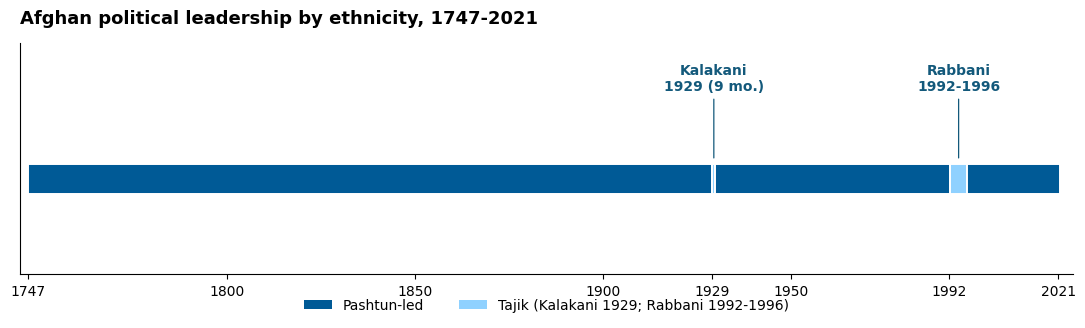


Pashtun-led rule: 269.4 of 274.6 years (98.1%)


In [7]:
fig, ax = plt.subplots(figsize=(11, 3.4))
group_colors = {'Pashtun': BRAND['blue_main'], 'Tajik': BRAND['blue_light']}

for _, row in timeline.iterrows():
    ax.barh(0, row['years'], left=row['start'], height=0.45,
            color=group_colors[row['group']], edgecolor='white', linewidth=1.4)

# Annotate Tajik exceptions with leader lines pointing UP, well clear of the bar
labels = {
    'Kalakani': 'Kalakani\n1929 (9 mo.)',
    'Rabbani':  'Rabbani\n1992-1996',
}
for _, row in timeline.iterrows():
    if row['group'] == 'Tajik':
        name = row['segment'].split('(')[0].strip()
        center = row['start'] + row['years']/2
        ax.annotate(labels.get(name, name),
                    xy=(center, 0.27),
                    xytext=(center, 1.30),
                    ha='center', fontsize=10, color=BRAND['title_blue'], fontweight='600',
                    arrowprops=dict(arrowstyle='-', color=BRAND['title_blue'], lw=0.9))

ax.set_xlim(1745, 2025)
ax.set_ylim(-1.4, 2.0)
ax.set_yticks([])
ax.set_xticks([1747, 1800, 1850, 1900, 1929, 1950, 1992, 2021])
ax.set_title('Afghan political leadership by ethnicity, 1747-2021')

# Legend below the bar so it never overlaps the timeline itself
ax.legend(handles=[Patch(facecolor=BRAND['blue_main'],  label='Pashtun-led'),
                   Patch(facecolor=BRAND['blue_light'], label='Tajik (Kalakani 1929; Rabbani 1992-1996)')],
          loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2,
          frameon=False, fontsize=10, columnspacing=2.5)
ax.grid(False)
plt.tight_layout()
plt.show()

pashtun_years = timeline[timeline['group']=='Pashtun']['years'].sum()
total_years   = timeline['years'].sum()
print(f"\nPashtun-led rule: {pashtun_years:.1f} of {total_years:.1f} years "
      f"({100*pashtun_years/total_years:.1f}%)")


---

## Chart 4 — Federalism vs. Post-Conflict Stability

A 0–5 author scoring across five multi-ethnic states. The point isn't that the scores are precise —
it's that the *pattern* across cases is what the comparative literature predicts: federalism alone is
not sufficient (Yugoslavia, Ethiopia), but its absence in a polarized society is reliably
destabilizing (Afghanistan).

**Scoring rubric**

- **Federalism** (0 = unitary, 3 = decentralized w/ partial autonomy, 5 = strong ethnic/linguistic
  federalism with real subnational policy authority)
- **Stability** (0 = state collapse, 2 = persistent civil conflict, 4 = stable with managed
  ethnic tensions, 5 = stable)


In [8]:
cases = pd.DataFrame([
    {'country': 'India',              'federalism': 5, 'stability': 4, 'note': '1956 States Reorganization Act; linguistic states; no group >40%'},
    {'country': 'Iraq',               'federalism': 3, 'stability': 2, 'note': '2005 constitution recognizes KRG; sectarian civil war + ISIS'},
    {'country': 'Ethiopia',           'federalism': 4, 'stability': 2, 'note': '1991 ethnic federalism; Tigray war'},
    {'country': 'Yugoslavia (1991)',  'federalism': 3, 'stability': 0, 'note': "Tito's federation; collapsed once authoritarian glue dissolved"},
    {'country': 'Afghanistan (2021)', 'federalism': 1, 'stability': 0, 'note': 'Highly centralized 2004 constitution; Pashtun-dominated state'},
])
cases


,country,federalism,stability,note
0,India,5,4,1956 States Reorganization Act; linguistic sta...
1,Iraq,3,2,2005 constitution recognizes KRG; sectarian ci...
2,Ethiopia,4,2,1991 ethnic federalism; Tigray war
3,Yugoslavia (1991),3,0,Tito's federation; collapsed once authoritaria...
4,Afghanistan (2021),1,0,Highly centralized 2004 constitution; Pashtun-...


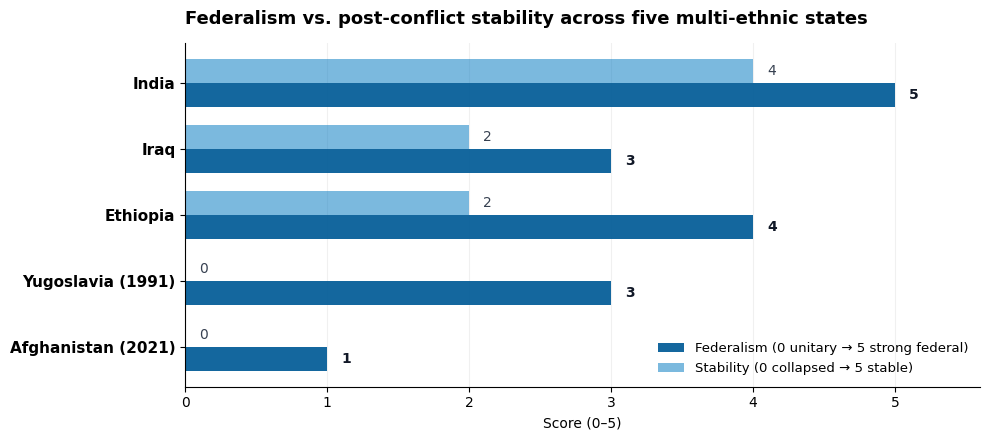

In [9]:
fig, ax = plt.subplots(figsize=(10, 4.5))
y = np.arange(len(cases))[::-1]
h = 0.36

ax.barh(y - h/2, cases['federalism'], h,
        color=BRAND['blue_main'], edgecolor='none', alpha=0.92,
        label='Federalism (0 unitary → 5 strong federal)')
ax.barh(y + h/2, cases['stability'],  h,
        color=BRAND['blue_soft'], edgecolor='none', alpha=0.55,
        label='Stability (0 collapsed → 5 stable)')

for i, row in cases.iterrows():
    yi = y[i]
    ax.text(row['federalism'] + 0.10, yi - h/2, str(row['federalism']),
            va='center', fontsize=10, color='#111827', fontweight='600')
    ax.text(row['stability']  + 0.10, yi + h/2, str(row['stability']),
            va='center', fontsize=10, color='#374151')

ax.set_yticks(y)
ax.set_yticklabels(cases['country'], fontsize=11, fontweight='600')
ax.set_xlim(0, 5.6)
ax.set_xticks(range(6))
ax.set_xlabel('Score (0–5)')
ax.set_title('Federalism vs. post-conflict stability across five multi-ethnic states')
ax.legend(loc='lower right', frameon=False, fontsize=9.5)
ax.grid(axis='x', alpha=0.18)
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()


---

## Sources

Numbered to match the live blog post.

1. National Museum of American Diplomacy — *The Marshall Plan*. https://diplomacy.state.gov/online-exhibits/diplomacy-is-our-mission/development/the-marshall-plan/
2. Costs of War Project, Watson Institute, Brown University — *Costs of the 20-year war on terror: $8 trillion and 900,000 deaths*, Brown News, September 1, 2021. https://www.brown.edu/news/2021-09-01/costsofwar
3. Gareth Price, Chatham House — *Why Afghan Nation-Building Was Always Destined to Fail*, September 2021. https://www.chathamhouse.org/2021/09/why-afghan-nation-building-was-always-destined-fail
4. Graeme Herd, George C. Marshall European Center for Security Studies — *The Causes and the Consequences of Strategic Failure in Afghanistan*, August 2021.
5. Alex Thier, U.S. Institute of Peace — *The Nature of the Afghan State: Centralization vs. Decentralization*, 2020.
6. Alesina & Spolaore, *The Size of Nations*, MIT Press, 2003; Alesina, *The Size of Countries: Does It Matter?*, JEEA 2003.
7. Enrico Spolaore — *Federalism, Regional Redistribution, and Country Stability*, Tufts Working Paper, 2008; Bakke & Wibbels, *Diversity, Disparity, and Civil Conflict in Federal States*, World Politics 2006.
8. Montalvo & Reynal-Querol — *Ethnic Polarization, Potential Conflict, and Civil Wars*, AER 2005.
9. Minority Rights Group International — *Afghanistan*, 2024. https://minorityrights.org/country/afghanistan/
10. Fernández-Villaverde, Koyama, Lin & Sng — *The Fractured-Land Hypothesis and State Formation in Eurasia*, 2022.
11. United Nations — *Bonn Agreement on Provisional Arrangements in Afghanistan*, December 5, 2001.
12. Al Jazeera — *Kabul burial of Tajik King Kalakani stirs tension*, September 2, 2016.
13. Jennifer Brick Murtazashvili — *The Collapse of Afghanistan*, Journal of Democracy, 2022.
14. Middle East Institute — *Taliban Leadership Tracker, Demographics*, 2024 (1,212 senior officials, ~90% Pashtun). https://talibantracker.mei.edu/english/taliban/demographics
15. Encyclopedia Britannica — *States Reorganization Act*.
16. Sardar Aziz, EISMENA — *Iraqi Federalism: The Second-Best Option for Everyone*, October 2023.
17. Alem Habtu — *Ethnic Federalism in Ethiopia*, 2003.
18. David Ottaway, Wilson Center — *Ethiopia Faces Dire Consequences of Ethnic Federalism*, July 2021.
19. W. Harriet Critchley — *The Failure of Federalism in Yugoslavia*, International Journal, 1993.
20. Jamestown Foundation — *The Warlords Return to Afghanistan: Atta Mohammad Noor*, 2021; Carter Malkasian, *The American War in Afghanistan: A History* (Oxford, 2021).
21. France 24 / AFP — *Afghan warlords give up to the Taliban with surprising ease*, August 15, 2021.
22. The Diplomat — *Ashraf Ghani and the Pashtun Dilemma*, January 2015; USIP — *One Year Later: Taliban Reprise Repressive Rule*, August 2022.

---

*Companion data for "One Country, Too Many Nations: What America Got Wrong in Afghanistan."
The country outline used in Chart 2 is derived from open vector data
([djaiss/mapsicon](https://github.com/djaiss/mapsicon), MIT-licensed).
Released under MIT for code, CC-BY-4.0 for data and prose. The original class paper is not part
of this public package.*
